# Price Variation Analysis

**Project Question:** How much do food prices vary across commodities and markets?


## 1. Load and Check Data


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('../images', exist_ok=True)
df = pd.read_csv('../data/processed/clean_prices.csv')

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Number of products:", df['product'].nunique())
print("Number of markets:", df['market'].nunique())

display(df['value'].describe())


Shape: (32504, 15)
Columns: ['country', 'market', 'admin_1', 'longitude', 'latitude', 'cpcv2', 'product', 'source_document', 'period_date', 'price_type', 'product_source', 'unit', 'unit_type', 'currency', 'value']
Number of products: 12
Number of markets: 22


count    32504.000000
mean        40.269373
std         24.160383
min          1.234000
25%         24.400000
50%         36.900000
75%         50.100000
max        239.000000
Name: value, dtype: float64

## 2. Commodity Price Variation


In [2]:
commodity_var = df.groupby('product')['value'].agg(
    observation_count='count',
    mean_price='mean',
    median_price='median',
    min_price='min',
    max_price='max',
    std_price='std'
).reset_index()

commodity_var['cv_percent'] = (commodity_var['std_price'] / commodity_var['mean_price']) * 100
commodity_var = commodity_var.sort_values(by='std_price', ascending=False)

display(commodity_var)


,product,observation_count,mean_price,median_price,min_price,max_price,std_price,cv_percent
0,Beans (Haricot),2576,50.836651,38.712,8.900,239.0,36.409233,71.620045
5,Refined sugar,2916,63.294606,54.000,22.000,220.0,25.692420,40.591801
4,Mixed Teff,2829,50.995801,45.000,24.000,230.0,19.739882,38.708838
10,Wheat Flour,1824,49.853490,45.000,20.600,113.0,19.589358,39.293855
8,Sorghum (White),2740,34.591417,30.000,9.600,114.0,17.655400,51.039829
7,Sorghum (Red),2902,30.841197,29.600,6.760,122.0,17.207552,55.794047
6,Rice (Milled),2821,48.681309,45.000,22.446,109.0,17.200794,35.333466
11,Wheat Grain,3317,38.512123,35.600,12.800,105.0,16.829647,43.699608
1,Firewood,3172,14.044567,9.300,1.234,230.0,16.816578,119.737246
9,Sorghum (Yellow),1252,36.426711,36.000,8.800,88.0,15.562457,42.722651


## 3. Identify High- and Low-Variation Commodities


In [3]:
print("--- 5 Commodities with Highest Standard Deviation ---")
display(commodity_var.head(5)[['product', 'std_price']])

print("\n--- 5 Commodities with Lowest Standard Deviation ---")
display(commodity_var.tail(5)[['product', 'std_price']])

commodity_var_cv = commodity_var.sort_values(by='cv_percent', ascending=False)
print("\n--- 5 Commodities with Highest CV (%) ---")
display(commodity_var_cv.head(5)[['product', 'cv_percent']])

print("\n--- 5 Commodities with Lowest CV (%) ---")
display(commodity_var_cv.tail(5)[['product', 'cv_percent']])


--- 5 Commodities with Highest Standard Deviation ---


,product,std_price
0,Beans (Haricot),36.409233
5,Refined sugar,25.692420
4,Mixed Teff,19.739882
10,Wheat Flour,19.589358
8,Sorghum (White),17.655400



--- 5 Commodities with Lowest Standard Deviation ---


,product,std_price
11,Wheat Grain,16.829647
1,Firewood,16.816578
9,Sorghum (Yellow),15.562457
2,Horse beans,14.831304
3,Maize Grain (White),14.579669



--- 5 Commodities with Highest CV (%) ---


,product,cv_percent
1,Firewood,119.737246
0,Beans (Haricot),71.620045
7,Sorghum (Red),55.794047
3,Maize Grain (White),55.266719
8,Sorghum (White),51.039829



--- 5 Commodities with Lowest CV (%) ---


,product,cv_percent
5,Refined sugar,40.591801
10,Wheat Flour,39.293855
4,Mixed Teff,38.708838
6,Rice (Milled),35.333466
2,Horse beans,32.145394


**Variation Explanation:**
- **Standard deviation** shows absolute variation in ETB/kg. A higher standard deviation means the price has a wider spread in absolute currency terms.
- **Coefficient of Variation (CV)** shows variation relative to the commodity's average price (standard deviation divided by the mean). A high CV indicates that the price varies significantly as a percentage of its own average cost.


## 4. Market Price Variation


In [4]:
market_var = df.groupby('market')['value'].agg(
    observation_count='count',
    mean_price='mean',
    median_price='median',
    min_price='min',
    max_price='max',
    std_price='std'
).reset_index()

market_var['cv_percent'] = (market_var['std_price'] / market_var['mean_price']) * 100
market_var = market_var.sort_values(by='std_price', ascending=False)

display(market_var)

print("--- 5 Markets with Highest Standard Deviation ---")
display(market_var.head(5)[['market', 'std_price']])

print("\n--- 5 Markets with Lowest Standard Deviation ---")
display(market_var.tail(5)[['market', 'std_price']])

market_var_cv = market_var.sort_values(by='cv_percent', ascending=False)
print("\n--- 5 Markets with Highest CV (%) ---")
display(market_var_cv.head(5)[['market', 'cv_percent']])

print("\n--- 5 Markets with Lowest CV (%) ---")
display(market_var_cv.tail(5)[['market', 'cv_percent']])


,market,observation_count,mean_price,median_price,min_price,max_price,std_price,cv_percent
20,Warder,1673,68.732407,56.000,12.000,239.0,37.432686,54.461481
9,Gode,1737,51.685320,48.600,4.600,173.0,33.315331,64.458015
5,Degehabour,1602,45.757428,40.800,4.680,132.0,28.104241,61.420062
21,Yabelo,1770,35.562704,32.852,1.484,120.0,23.071125,64.874496
12,Mekele,340,32.788465,24.550,11.000,200.0,22.407411,68.339312
0,"Addis Ababa, Merkato",2138,43.379878,42.400,3.280,120.0,21.868070,50.410629
11,Logia,1014,48.089004,45.000,12.500,230.0,21.409833,44.521265
17,Shire,498,32.227761,25.690,2.148,100.0,21.023382,65.233765
2,Bahir Dar,1683,39.588197,40.400,2.510,112.0,20.787055,52.508212
8,Gambella,1495,37.499632,34.800,7.200,130.8,20.711469,55.231125


--- 5 Markets with Highest Standard Deviation ---


,market,std_price
20,Warder,37.432686
9,Gode,33.315331
5,Degehabour,28.104241
21,Yabelo,23.071125
12,Mekele,22.407411



--- 5 Markets with Lowest Standard Deviation ---


,market,std_price
6,Dessie,19.441869
3,Beddenno,19.145550
16,Shashemene,18.082935
13,"Nazareth, Adama",17.527264
4,Chereti,15.503173



--- 5 Markets with Highest CV (%) ---


,market,cv_percent
12,Mekele,68.339312
17,Shire,65.233765
21,Yabelo,64.874496
9,Gode,64.458015
14,Nekemte,64.307556



--- 5 Markets with Lowest CV (%) ---


,market,cv_percent
13,"Nazareth, Adama",48.880901
16,Shashemene,47.709510
11,Logia,44.521265
1,Awash,42.070191
4,Chereti,36.711078


## 5. Create Charts


C:\Users\hp\AppData\Local\Temp\ipykernel_10716\1966899964.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='std_price', y='product', data=commodity_var, palette='Reds_r')


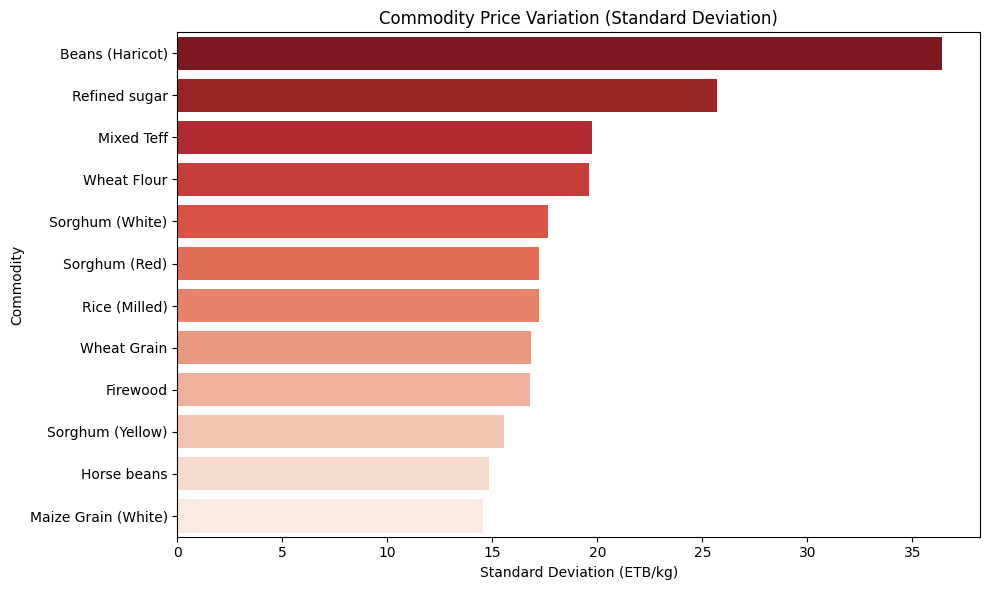

In [5]:
# CHART 1: Commodity price variation using standard deviation
plt.figure(figsize=(10, 6))
sns.barplot(x='std_price', y='product', data=commodity_var, palette='Reds_r')
plt.title('Commodity Price Variation (Standard Deviation)')
plt.xlabel('Standard Deviation (ETB/kg)')
plt.ylabel('Commodity')
plt.tight_layout()
plt.savefig('../images/commodity_price_variation_std.png')
plt.show()


C:\Users\hp\AppData\Local\Temp\ipykernel_10716\2449085729.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='cv_percent', y='product', data=commodity_var_cv, palette='Blues_r')


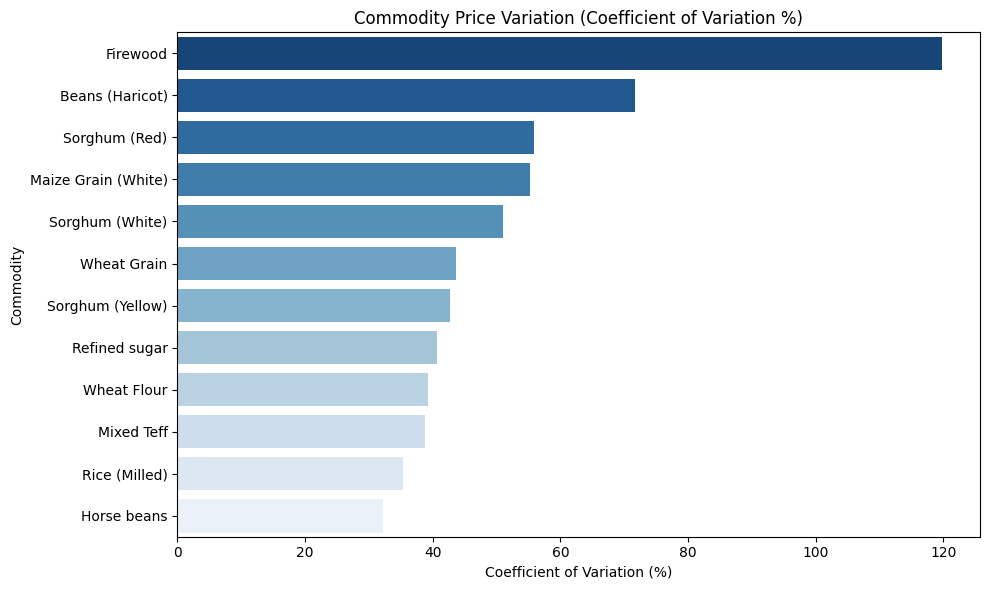

In [6]:
# CHART 2: Commodity coefficient of variation
plt.figure(figsize=(10, 6))
sns.barplot(x='cv_percent', y='product', data=commodity_var_cv, palette='Blues_r')
plt.title('Commodity Price Variation (Coefficient of Variation %)')
plt.xlabel('Coefficient of Variation (%)')
plt.ylabel('Commodity')
plt.tight_layout()
plt.savefig('../images/commodity_price_variation_cv.png')
plt.show()


C:\Users\hp\AppData\Local\Temp\ipykernel_10716\285850539.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='std_price', y='market', data=market_var, palette='Greens_r')


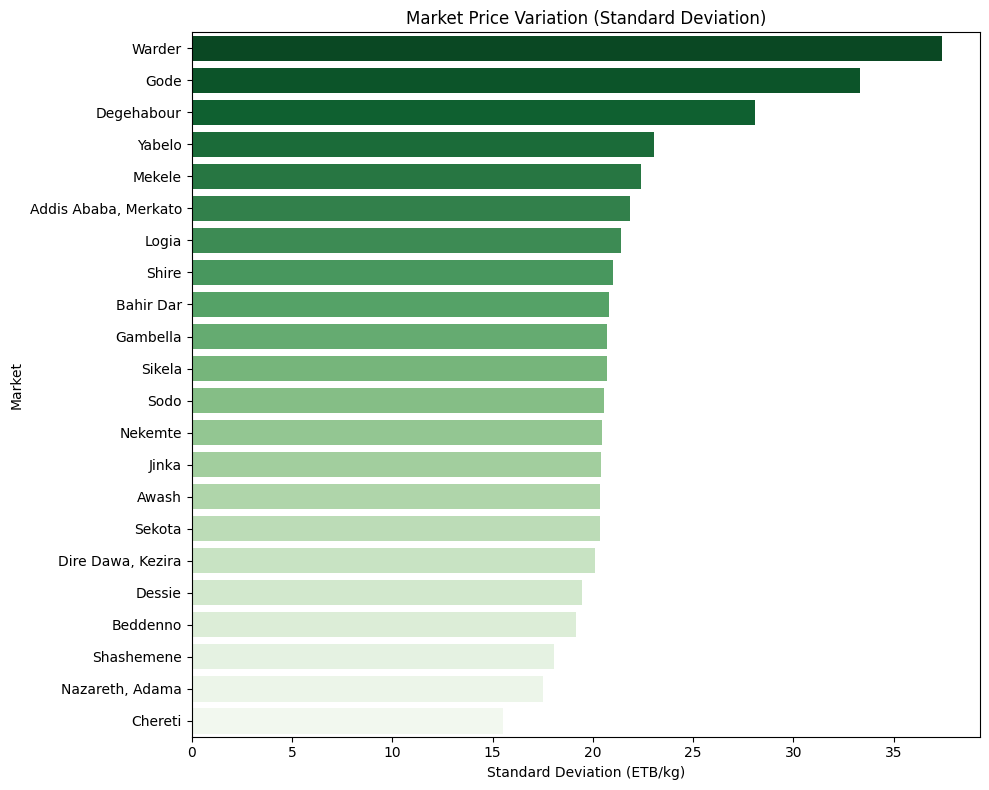

In [7]:
# CHART 3: Market price variation using standard deviation
plt.figure(figsize=(10, 8))
sns.barplot(x='std_price', y='market', data=market_var, palette='Greens_r')
plt.title('Market Price Variation (Standard Deviation)')
plt.xlabel('Standard Deviation (ETB/kg)')
plt.ylabel('Market')
plt.tight_layout()
plt.savefig('../images/market_price_variation_std.png')
plt.show()


## 6. Interpret the Results

Based on the calculations above:

1. **Which commodities show the greatest absolute price variation?**  
   Beans (Haricot) (36.41 ETB/kg) and Refined sugar (25.69 ETB/kg) have the highest absolute standard deviations.
2. **Which commodities show the greatest relative price variation?**  
   Firewood has the highest CV (119.74%), meaning its price varies immensely relative to its average price, followed by Beans (Haricot) (71.62%).
3. **Which commodities are relatively stable?**  
   Horse beans (32.15% CV) and Rice (Milled) (35.33% CV) show the lowest relative variation. In absolute terms, Maize Grain (White) (14.58 ETB/kg) and Horse beans (14.83 ETB/kg) have the lowest standard deviations.
4. **Which markets show the greatest price variation?**  
   Warder has the greatest absolute variation with a standard deviation of 37.43 ETB/kg. In relative terms, Mekele has the highest CV at 68.34%.
5. **Which markets show relatively lower variation?**  
   Chereti has the lowest variation in both absolute terms (15.50 ETB/kg std) and relative terms (36.71% CV). 
6. **Does the ranking change when using standard deviation versus CV?**  
   Yes. For example, Firewood has a relatively low absolute variation (16.82 ETB/kg, one of the lowest) but has the highest relative variation (CV = 119.74%) because its mean price is low. For markets, Warder has the highest standard deviation but Mekele has the highest CV.
7. **What is the most important price-variation finding for this project?**  
   The most important finding is that variation is highly dependent on whether we measure it absolutely or relatively; commodities with lower average prices (like Firewood) can have massive relative volatility, while markets like Warder have high absolute spread across all tracked goods.


## 7. Limitations

- **Descriptive, not explanatory:** Standard deviation and CV describe variation but do not explain its cause.
- **Observation bias:** Some commodities and markets have different numbers of observations, which can skew standard deviations.
- **Scope restriction:** The analysis is based only on Retail prices measured in kg.
- **Fixed comparable base:** The cleaned dataset contains 12 comparable commodities.
- **Availability dependence:** Market and commodity averages/variation heavily depend on the available observations and what is actually traded there.
- **No causation:** This analysis does not establish causation for why certain markets or commodities are more volatile than others.
